In [29]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("safaruzzamanshovo/graduate-admission-dataset")

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/safaruzzamanshovo/graduate-admission-dataset/versions/1


In [30]:
import pandas as pd
df = pd.read_csv("/root/.cache/kagglehub/datasets/safaruzzamanshovo/graduate-admission-dataset/versions/1/graduate_admission1.csv")

In [31]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train,y_test = train_test_split(df.drop("Chance of Admit" , axis = 1) , df['Chance of Admit'] , train_size = 0.8 , random_state  = True)

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [33]:
import torch
X_train_tensor = torch.tensor(X_train , dtype = torch.float32)
X_test_tensor = torch.tensor(X_test , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32)

In [45]:
import torch.nn as nn
import torch.optim as optim
class Model(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(num_features , 6),
        nn.Linear(6 , 1)
    )
  def forward(self , X):
    output = self.net(X)
    return output

In [65]:
lr = 0.05
num_features = X_train_tensor.shape[1]
model = Model(num_features)
epochs = 100
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),lr)

In [66]:
y_train_tensor = y_train_tensor.unsqueeze(1).float()
Loss = []
for epoch in range(epochs):
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    Loss.append(loss)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([800, 1, 1, 1, 1, 1, 1, 1])) that is different to the input size (torch.Size([800, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/100], Loss: 1.1078
Epoch [2/100], Loss: 0.7793
Epoch [3/100], Loss: 0.5605
Epoch [4/100], Loss: 0.4110
Epoch [5/100], Loss: 0.3072
Epoch [6/100], Loss: 0.2343
Epoch [7/100], Loss: 0.1827
Epoch [8/100], Loss: 0.1457
Epoch [9/100], Loss: 0.1188
Epoch [10/100], Loss: 0.0991
Epoch [11/100], Loss: 0.0843
Epoch [12/100], Loss: 0.0730
Epoch [13/100], Loss: 0.0642
Epoch [14/100], Loss: 0.0571
Epoch [15/100], Loss: 0.0514
Epoch [16/100], Loss: 0.0467
Epoch [17/100], Loss: 0.0428
Epoch [18/100], Loss: 0.0394
Epoch [19/100], Loss: 0.0364
Epoch [20/100], Loss: 0.0339
Epoch [21/100], Loss: 0.0316
Epoch [22/100], Loss: 0.0296
Epoch [23/100], Loss: 0.0278
Epoch [24/100], Loss: 0.0262
Epoch [25/100], Loss: 0.0248
Epoch [26/100], Loss: 0.0234
Epoch [27/100], Loss: 0.0223
Epoch [28/100], Loss: 0.0212
Epoch [29/100], Loss: 0.0202
Epoch [30/100], Loss: 0.0193
Epoch [31/100], Loss: 0.0185
Epoch [32/100], Loss: 0.0177
Epoch [33/100], Loss: 0.0171
Epoch [34/100], Loss: 0.0164
Epoch [35/100], Loss: 0

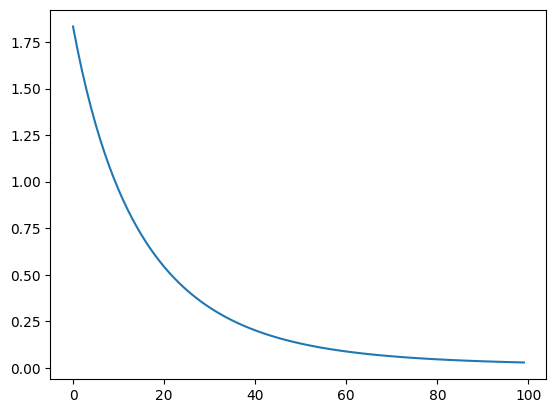

In [60]:
import matplotlib.pyplot as plt
plt.plot([l.detach().numpy() for l in Loss])

In [67]:
from sklearn.metrics import mean_absolute_error
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).cpu().numpy()
    y_true = y_test_tensor.cpu().numpy()
error = mean_absolute_error(y_pred , y_true)
print(error)

0.08097986876964569
